# Activity 4: Customer Churn Prediction
### Logistic Regression Model (Slide 19 of `ML_Lab_3.pptx`)
**Dataset:** `WA_Fn-UseC_-Telco-Customer-Churn.csv`  
**Objective:** Predict whether a customer will churn based on behavior, contract, and usage patterns.

---

### Slide 19 Instructions:
1. **Load dataset** and preprocess categorical variables (Encoding).
2. **Train a Logistic Regression model** with features like `tenure`, `MonthlyCharges`, `Contract`, `InternetService`.
3. **Evaluate** using **Accuracy, Precision, Recall, F1-score**.
4. **Plot Confusion Matrix & ROC Curve**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

# Load dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
features_req = ['tenure', 'MonthlyCharges', 'Contract', 'InternetService']
print(df[features_req + ['Churn']].head())

Dataset Shape: 7043 rows, 21 columns
   tenure  MonthlyCharges        Contract InternetService Churn
0      45           89.86        Two year     Fiber optic    No
1      35           52.71  Month-to-month             DSL    No
2      47           22.03        Two year              No    No
3      20           70.06        Two year             DSL    No
4       2           24.01  Month-to-month              No    No

## Step 1 — Categorical Preprocessing & Encoding (Slide 19)

In [2]:
# Define X and y
X_raw = df[['tenure', 'MonthlyCharges', 'Contract', 'InternetService']].copy()
y = df['Churn'].map({'Yes': 1, 'No': 0}).values

# One-hot encode Contract and InternetService
X_encoded = pd.get_dummies(X_raw, columns=['Contract', 'InternetService'], drop_first=True, dtype=int)
print("Encoded Feature Columns:")
for col in X_encoded.columns:
    print(" -", col)

print("\nEncoded feature head:")
print(X_encoded.head())

Encoded Feature Columns:
 - tenure
 - MonthlyCharges
 - Contract_One year
 - Contract_Two year
 - InternetService_Fiber optic
 - InternetService_No

Encoded feature head:
   tenure  MonthlyCharges  ...  InternetService_Fiber optic  InternetService_No
0      45           89.86  ...                            1                   0
1      35           52.71  ...                            0                   0
2      47           22.03  ...                            0                   1
3      20           70.06  ...                            0                   0
4       2           24.01  ...                            0                   1

[5 rows x 6 columns]

## Step 2 — Train/Test Split & Scaling

In [3]:
X = X_encoded.values

# 80/20 Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training shape:", X_train_scaled.shape, " Testing shape:", X_test_scaled.shape)

Training shape: (5634, 6)  Testing shape: (1409, 6)

## Step 3 — Train Logistic Regression Model & Evaluate (Slide 19)

In [4]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("=" * 45)
print("   SLIDE 19 LOGISTIC REGRESSION EVALUATION   ")
print("=" * 45)
print(f"  Accuracy:   {acc:.4f} ({acc*100:.2f}%)")
print(f"  Precision:  {prec:.4f} ({prec*100:.2f}%)")
print(f"  Recall:     {rec:.4f} ({rec*100:.2f}%)")
print(f"  F1-Score:   {f1:.4f} ({f1*100:.2f}%)")
print(f"  ROC-AUC:    {auc:.4f} ({auc*100:.2f}%)")
print("=" * 45)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

   SLIDE 19 LOGISTIC REGRESSION EVALUATION   
  Accuracy:   0.7970 (79.70%)
  Precision:  0.6905 (69.05%)
  Recall:     0.5101 (51.01%)
  F1-Score:   0.5867 (58.67%)
  ROC-AUC:    0.8463 (84.63%)

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      1011
           1       0.69      0.51      0.59       398

    accuracy                           0.80      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409


## Step 4 — Plot Confusion Matrix & ROC Curve (Required in Slide 19)

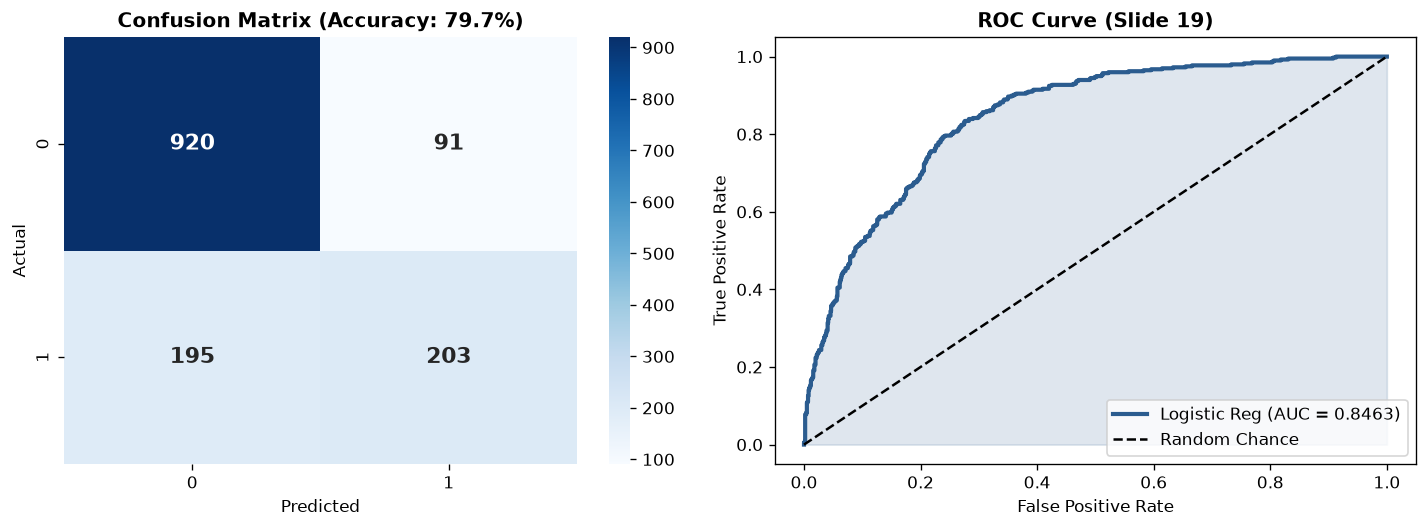

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], annot_kws={'size': 13, 'weight': 'bold'})
axes[0].set_title(f"Confusion Matrix (Accuracy: {acc*100:.1f}%)", fontweight='bold')
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#2b5c8f', lw=2.5, label=f'Logistic Reg (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance')
axes[1].fill_between(fpr, tpr, alpha=0.15, color='#2b5c8f')
axes[1].set_title("ROC Curve (Slide 19)", fontweight='bold')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()